## Build the Internal things 

In [10]:
import warnings
warnings.filterwarnings('ignore') 
# PDF fetch 
from langchain_community.document_loaders import PyPDFLoader 
try:
    loader  = PyPDFLoader('Why_Language_Models_Hallucinate_Explainer.pdf')
    pages = loader.load()
except Exception as e :
    print(str(e))
    
# Split the given document 
from langchain_text_splitters import RecursiveCharacterTextSplitter 
text_spliter = RecursiveCharacterTextSplitter(chunk_size=1200 , chunk_overlap=180)
texts = text_spliter.split_documents(pages)

chunks=[i.page_content for  i in texts]
metadata = [i.metadata for i in texts]

import hashlib 
ids=[hashlib.md5(chunk.encode('utf-8')).hexdigest() for chunk in chunks]


In [9]:
# VectorDB create 
import chromadb
from chromadb.utils.embedding_functions import DefaultEmbeddingFunction 
embedding_function = DefaultEmbeddingFunction()

client = chromadb.PersistentClient(path="./VectorDB")

collection = client.get_or_create_collection(name="System",embedding_function=embedding_function)

if collection.count()!=len(chunks):
    collection.upsert(
        documents=chunks,
        ids=ids , 
        metadatas=metadata
    )
collection.count()

17

In [12]:
# Hybrid connection
from rank_bm25 import BM25Okapi 
token_corpus = [i.split() for i in chunks]
tokens = BM25Okapi(token_corpus)
tokens

In [15]:
# Langgraph State Building 
from langgraph.graph import StateGraph , START 
from typing import Annotated ,TypedDict 
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list,add_messages]
    
# LLM connection 
from langchain_groq import ChatGroq 
import os 
from dotenv import load_dotenv 
load_dotenv()
os.getenv('GROQ_API_KEY')
LLM = ChatGroq(model='openai/gpt-oss-120b')
response = LLM.invoke('hello')
response.content

'Hello! How can I assist you today?'

In [36]:
# Hybrid Retrival 
from langchain_core.messages import AIMessage
def Hybrid_Rag(state:State):   
    query = state['messages'][-1].content
    prompt = f""" 
    write the query based on only for symentic and keyword search :
    {query} """
    query_rewrite = LLM.invoke(prompt).content
    
    result = collection.query(query_texts=[query_rewrite] , n_results=3)
    distances = result['distances'][0]
    documents = result['documents'][0]
    print(distances)
    threshold = 1.5
    dense_chunks = []
    for dis , doc in zip(distances,documents):
        if threshold > dis :
            dense_chunks.append(doc)
        # Keyword search connection
    scores = tokens.get_scores(query_rewrite.split())
    def get_keywords(scores,k=10):
        index = list(enumerate(scores))
        sorted_index = sorted(index , key = lambda x:x[1] , reverse=True)
        return [doc for doc , i in sorted_index[:k]]
    keywords=get_keywords(scores=scores , k=10)
    get_docs=[chunks[i]for i in keywords]
    
    rrf_tokens={}
    for rank , doc in enumerate(dense_chunks):
        rrf_tokens[doc] = rrf_tokens.get(doc,0)+1/(rank+60)
    for rank,doc in enumerate(get_docs):
        rrf_tokens[doc] = rrf_tokens.get(doc,0)+1/(rank+60)
    
    marge = sorted(rrf_tokens.items(),key=lambda x:x[1] , reverse=True)
    top_docs = [i for i , x in marge[:5]]
    
    if not top_docs:
        content = "Not related content"
    
    else : content = "\n\n".join(top_docs)
    return {"messages": [AIMessage(content=f"Retrieved Context: {content}")]}

In [37]:
# Tool creation 
from langchain_core.tools import tool 
from langchain_community.tools import DuckDuckGoSearchRun
import requests 
import numexpr 
# calculator 
@tool 
def calculator(execution:str):
    """ 
    Do all the user provided arithmetic calculation by this tool 
    """
    try:
        result = numexpr.evaluate(execution)
        return str(result)
    except Exception as e :
        return str(e)
#weather   
@tool 
def weather(location:str):
    """
    Fetch the user provided location's Weather
    """
    try:
        response = requests.get(url=f"https://wttr.in/{location}?format=3").text
        return response 
    except Exception as e :
        return str(e)
# websearch 
@tool 
def web_search(query:str):
    """If retrival fails to give data use this tool"""
    try:
        search  = DuckDuckGoSearchRun()
        return search.run(query)
    except Exception as e :
        return str(e)
    
import os

@tool
def file_handler(operation: str, file_path: str, content: str = ""):
    """
    Handles basic file operations such as create, read, append, and delete.
    """

    if operation == "create":
        with open(file_path, "w") as file:
            file.write(content)
        return f"File created: {file_path}"

    elif operation == "read":
        with open(file_path, "r") as file:
            return file.read()

    elif operation == "append":
        with open(file_path, "a") as file:
            file.write(content)
        return f"Content added to: {file_path}"

    elif operation == "delete":
        if os.path.exists(file_path):
            os.remove(file_path)
            return f"File deleted: {file_path}"
        return "File not found."

    else:
        return "Invalid operation."

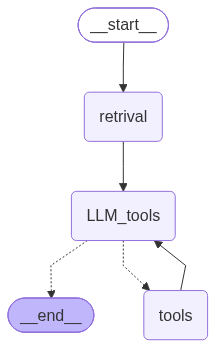

In [55]:
#tool blind 
tools=[weather,calculator,web_search,file_handler]
LLM_tool=LLM.bind_tools(tools)

from langgraph.checkpoint import memory 
memory = memory.MemorySaver()

# connection 
def tool_connection(state:State):
    response = LLM_tool.invoke(state['messages'])
    return {'messages':response}

# connection state 
Graph = StateGraph(State)
from langgraph.prebuilt import tools_condition , ToolNode 

# Edge builder
Graph.add_node('retrival',Hybrid_Rag)
Graph.add_node('LLM_tools',tool_connection)
Graph.add_node('tools',ToolNode(tools))

# Building node 
Graph.add_edge(START,'retrival')
Graph.add_edge('retrival','LLM_tools')
Graph.add_conditional_edges(
    'LLM_tools',
    tools_condition ,
    {"tools": "tools", "__end__": "__end__"},   
)
Graph.add_edge('tools','LLM_tools')

config = {'configurable':
    {"thread_id": "user_1"}
    }

connention = Graph.compile(memory)
connention

In [56]:
from langchain_core.messages import HumanMessage

question = "what is the current weather in kolkata and situation?"
for chunk in connention.stream(
    {
        "messages": [
            HumanMessage(content=question)
        ]
    },
    config=config
):
    print(chunk)

[1.532747745513916, 1.5638513565063477, 1.5908203125]
{'retrival': {'messages': [AIMessage(content="Retrieved Context: 1\n Why Language Models Hallucinate: A Statistical Account\n A Summary and Synthesis of Current Research  |  Compiled 2026\nABSTRACT\n Hallucination — the tendency of large language models (LLMs) to produce fluent, confident, and factually\nwrong statements — is often described as mysterious or unpredictable. Recent theoretical work, most\nnotably by Kalai, Nachum, Vempala, and Zhang (2025), argues the opposite: hallucination is a natural and\nlargely predictable consequence of how models are trained and graded, not an unexplained quirk of scale.\nThis document synthesizes that argument alongside supporting survey literature, covering the pretraining\norigins of factual error, why post-training and benchmarking fail to eliminate it, the specific error categories\nthat resist correction regardless of model size, and the mitigation strategies — including retrieval-augmen

In [49]:
from langchain_core.messages import HumanMessage
response=connention.invoke({'messages':[HumanMessage(content="what is the current weather in kolkata and situation?")]},config=config)
result = response['messages'][-1].content
result

[1.6683428287506104, 1.7225337028503418, 1.723183512687683]


'**Current weather in Kolkata (as of the latest data):**  \n\n- **Condition:** Partly cloudy ☁️  \n- **Temperature:** Around **30\u202f°C** (86\u202f°F)  \n- **Humidity:** Moderate  \n- **Wind:** Light breezes  \n\n**Situation / Outlook:**  \n- The day is generally pleasant with a mix of sun and clouds.  \n- No immediate severe weather warnings (e.g., storms or heavy rain) are in effect.  \n- Expect temperatures to stay in the low‑30\u202f°C range through the afternoon, with a slight chance of brief showers later in the evening as the monsoon season approaches.  \n\nFeel free to let me know if you need a longer forecast, specific activity recommendations, or any other details!'

## DataBase creation 

In [47]:
from sqlalchemy import Integer , Column , String , create_engine 
from sqlalchemy.orm import DeclarativeBase , sessionmaker 

# Create URL 
DATABASE_URL="sqlite:///.SQL_DataBase.db"

# Create engine 
engine = create_engine(url=DATABASE_URL , connect_args={'check_same_thread':False})

# declare base 
class base(DeclarativeBase):
    pass
# session create 
session = sessionmaker(bind=engine , autoflush=False , autocommit=False)

# Create DB 
class QueryHistory(base):
    __tablename__ = "Database_FAST"
    user_id = Column(Integer , autoincrement=True , primary_key=True)
    question = Column(String)
    limit = Column(Integer)
    answer = Column(String)
base.metadata.create_all(bind=engine)

def create_db():
    db = session()
    try: 
        yield db 
    finally : 
        db.close()

# Fast API connection 

In [ ]:
from fastapi import FastAPI ,HTTPException , Depends
from database import QueryHistory , create_db
app = FastAPI(title="api_system")
from pydantic import BaseModel

class QusAns(BaseModel):
    question : str 
    user_id : int = None 
    limit : int = 100 
    
@app.put("/ask")
def update(request:QusAns , db=Depends(create_db)):
    question = db.query(QueryHistory).filter(QueryHistory.user_id == request.user_id).first()
    if not question:
        raise HTTPException(status_code=400 , detail="questions not find out")
    question.question = request.question 
    db.commit()
    db.refresh(question)
    
    return question

@app.get("/ask")
def fetch(db = Depends(create_db)):
    try:
        questions = db.query(QueryHistory).all()
        return [
              {"id": q.id, "question": q.question, "answer": q.answer, "user_id": q.user_id}
              for q in questions
          ]
    except Exception as e:
        raise HTTPException(status_code=400 , detail=str(e))
    
@app.delete("/ask")
def delete(requests:QusAns , db=Depends(create_db)):
    question = db.query(QueryHistory).filter(QueryHistory.user_id == requests.user_id).first()
    
    if not question:
        raise HTTPException(status_code=400 , detail="no valid question")
    delete = question.id
    db.delete(question)
    db.commit()
    
    return {
        'status':'deleted',
        'delete':delete
    }
    

@app.post("/chat")
def Question_Answer(request:QusAns , db=Depends(create_db)):
    try:
        result = connention.invoke({
            'messages':
                [HumanMessage(content=request.question)]
        })
        answer = result['messages'][-1].content

        db_question = QueryHistory(
            question = request.question , 
            user_id = request.user_id , 
            limit = request.limit , 
            answer = answer
        )

        db.add(db_question)
        db.commit()
        db.refresh(db_question)
        
        return {
            
            'question':db_question.question,
            'limit':db_question.limit,
            'id': db_question.id , 
            'answer':answer
        }
    except Exception as e :
        raise HTTPException(status_code=400 , detail=str(e))
